## Univariate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
SEED = 42

In [3]:
# Load the CSV
url = "https://raw.githubusercontent.com/gchandra10/filestorage/main/FuelConsumptionCo2.csv"

# url = "FuelConsumptionCo2.csv"
df = pd.read_csv(url)

In [4]:
# Keep only the two columns we need
data = df[["ENGINESIZE", "CO2EMISSIONS"]].copy()

In [5]:
print(data.head())
print(data.describe())

   ENGINESIZE  CO2EMISSIONS
0         2.0           196
1         2.4           221
2         1.5           136
3         3.5           255
4         3.5           244
        ENGINESIZE  CO2EMISSIONS
count  1067.000000   1067.000000
mean      3.346298    256.228679
std       1.415895     63.372304
min       1.000000    108.000000
25%       2.000000    207.000000
50%       3.400000    251.000000
75%       4.300000    294.000000
max       8.400000    488.000000


In [6]:
# Train/test split (80/20) with shuffling for fairness
X = data[["ENGINESIZE"]]          # 2D array for sklearn
y = data["CO2EMISSIONS"]          # 1D array
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

In [7]:
# Fit a simple linear regression
regr = LinearRegression()
regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Evaluate on the test set
y_pred = regr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

- Mean Absolute Error - On avg, how far off are the predictions.
- Mean Square Error - avg of squared errors. 0 or closer to zero no errors.
- R2 - closer to 1 means better fit.

In [9]:
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² : {r2:.3f}")

MAE: 24.10
MSE: 985.94
R² : 0.762


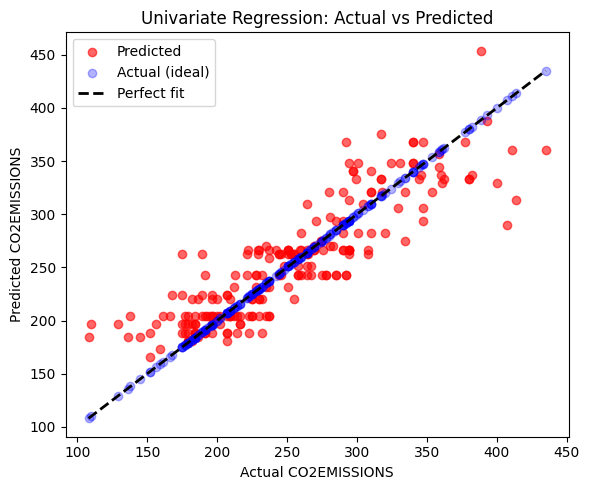

In [10]:
# Visualization: Actual vs Predicted (Univariate)
plt.figure(figsize=(6, 5))

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, color="red", alpha=0.6, label="Predicted")
plt.scatter(y_test, y_test, color="blue", alpha=0.3, label="Actual (ideal)")

# Perfect-fit line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2, label="Perfect fit")

plt.xlabel("Actual CO2EMISSIONS")
plt.ylabel("Predicted CO2EMISSIONS")
plt.title("Univariate Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
## MLFlow logging (optional)

In [12]:

import mlflow
import mlflow.sklearn
import pathlib

In [15]:
# Put mlruns under the current project folder and use it explicitly
tracking_dir = pathlib.Path.cwd().resolve() / "mlruns"
mlflow.set_tracking_uri(tracking_dir.as_uri())
print("Tracking URI:", mlflow.get_tracking_uri())

mlflow.set_experiment("emission_demo")

Tracking URI: file:///Users/ganesh.chandra/Documents/demos/codebase/uni_multi_model/mlruns


<Experiment: artifact_location='file:///Users/ganesh.chandra/Documents/demos/codebase/uni_multi_model/mlruns/138623722757278916', creation_time=1757904098854, experiment_id='138623722757278916', last_update_time=1757904098854, lifecycle_stage='active', name='emission_demo', tags={}>

In [16]:
from mlflow.models import infer_signature
import numpy as np

import matplotlib.pyplot as plt

with mlflow.start_run(run_name="univariate") as run:
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)

    # --- metrics ---
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2  = r2_score(y_test, y_pred)

    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2",  r2)

    # --- figure ---
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_test, y_pred, color="red", alpha=0.6, label="Predicted")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            "k--", lw=2, label="Perfect fit")
    ax.set_xlabel("Actual CO2EMISSIONS")
    ax.set_ylabel("Predicted CO2EMISSIONS")
    ax.set_title("Univariate Regression: Actual vs Predicted")
    ax.legend()

    # log the figure to Artifacts
    mlflow.log_figure(fig, "pred_vs_actual.png")
    plt.close(fig)   # close so it doesn’t keep showing in notebook

    # --- model ---
    signature = infer_signature(X_train, regr.predict(X_train))
    input_example = X_test.iloc[:3]
    
    model_info = mlflow.sklearn.log_model(
        sk_model=regr,
        name="lr_model",
        signature=signature,
        input_example=input_example,
        registered_model_name="UnivariateLinearRegressionModel",
        pip_requirements=[
            "mlflow>=2.15.1,<4.0",
            "scikit-learn>=1.5,<1.8",
            "pandas>=2.2,<2.4",
            "numpy>=2.1,<2.4",
        ],
    )
    
    mlflow.set_logged_model_tags(
      model_info.model_id, {"version": "v1", "type": "univariate"}
    )

    print("Run logged with ID:", run.info.run_id)


2025/09/14 22:46:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run logged with ID: 9fd4cc293dcf42be8cbbccd6e6181471


Successfully registered model 'UnivariateLinearRegressionModel'.
Created version '1' of model 'UnivariateLinearRegressionModel'.


Command Prompt start 

```mlflow ui --backend-store-uri <tracking URI>```

Open http://127.0.0.1:5000

export MLFLOW_TRACKING_URI="file:///Users/ganesh.chandra/Documents/demos/codebase/uni_multi_model/mlruns"

mlflow models serve -m runs:/9fd4cc293dcf42be8cbbccd6e6181471/lr_model --port 5001 --env-manager local


mlflow models serve -m runs:/<RUN_ID>/lr_model --port 5001

curl -X post "http://127.0.0.1:5001/invocations" -H "Content-Type:application/json" --data '{"columns":["ENGINESIZE"],"data":[[2.0],[3.0],[4.0]]}'